# Week 3 – CNN Embeddings on Vehicle Damage Images

## Objective
Learn how Convolutional Neural Networks automatically learn
useful representations from vehicle damage images.


In [10]:
# TODO: Import required libraries
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import json


## Step 1: Load and Preprocess Dataset


In [13]:
import os
import cv2
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# --- CONFIGURATION ---
IMAGE_DIR = r"D:/archive/image/image"  # Update this path
ANNOTATION_FILE = r"D:/archive/0Train_via_annos.json"    # Path to your JSON file
IMG_SIZE = (128, 128)
MAX_SAMPLES = 250

# Mapping Vietnamese labels to numbers
class_map = {"mat_bo_phan": 0, "rach": 1, "mop_lom": 2, "tray_son": 3}
inv_map = {v: k for k, v in class_map.items()}

X = []
y = []

with open(ANNOTATION_FILE) as f:
    annotations = json.load(f)

print(f"Loading up to {MAX_SAMPLES} samples...")

count = 0
for img_id, info in annotations.items():
    if count >= MAX_SAMPLES: break
    
    img_path = os.path.join(IMAGE_DIR, info['name'])
    full_img = cv2.imread(img_path)
    if full_img is None: continue

    for region in info['regions']:
        if count >= MAX_SAMPLES: break
        
        label = region['class']
        if label not in class_map: continue

        # Get crop coordinates
        xs, ys = region['all_x'], region['all_y']
        x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
        
        # Crop and resize
        crop = full_img[y1:y2, x1:x2]
        if crop.size == 0: continue
        
        crop = cv2.resize(crop, IMG_SIZE)
        X.append(crop.astype('float32') / 255.0)
        y.append(class_map[label])
        count += 1

X = np.array(X)
y_cat = tf.keras.utils.to_categorical(y, num_classes=len(class_map))

print(f"Done! Prepared {len(X)} samples.")

Loading up to 250 samples...
Done! Prepared 250 samples.


## Step 2: Define CNN Architecture
Build a small CNN to learn image features.


In [21]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu', name='dense_embeddings'), # Embedding Layer
    layers.Dense(len(class_map), activation='softmax')
])

## Step 3: Train the CNN
This step will take time

In [22]:


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X, y_cat, epochs=10, batch_size=16, validation_split=0.2)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.3750 - loss: 3.6788 - val_accuracy: 0.7000 - val_loss: 1.0975
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5250 - loss: 1.2160 - val_accuracy: 0.5800 - val_loss: 1.1917
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6150 - loss: 0.9756 - val_accuracy: 0.2400 - val_loss: 1.5690
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.6800 - loss: 0.8354 - val_accuracy: 0.7600 - val_loss: 0.8311
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.7700 - loss: 0.6323 - val_accuracy: 0.6800 - val_loss: 0.9009
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.8400 - loss: 0.5087 - val_accuracy: 0.7000 - val_loss: 0.8074
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8850 - loss: 0.3636 - val_accuracy: 0.5600 - val_loss: 1.3428
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8950 - loss: 0.3376 - val_accuracy: 0.4800 - 

## Step 4: Extract CNN Embeddings
Extract features from the penultimate layer.


In [23]:
# Build a new model with only the layers we want (up to the 128-unit Dense layer)
embedding_model = models.Sequential()
for layer in model.layers[:-1]: # Take all layers EXCEPT the last softmax layer
    embedding_model.add(layer)

# Now extract the embeddings
cnn_embeddings = embedding_model.predict(X)
print("Embeddings shape:", cnn_embeddings.shape) # Should be (250, 128)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Embeddings shape: (250, 128)


## Step 5: PCA / t-SNE on CNN Embeddings
Visualize learned representations.


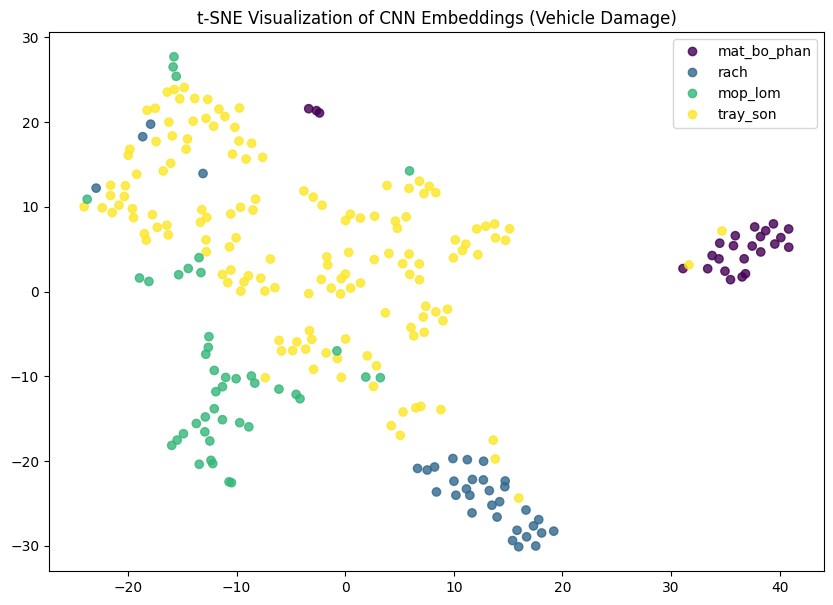

In [24]:
# TODO: Apply PCA or t-SNE to CNN embeddings
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
vis_dims = tsne.fit_transform(cnn_embeddings)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=y, cmap='viridis', alpha=0.8)
plt.legend(handles=scatter.legend_elements()[0], labels=[inv_map[i] for i in range(len(class_map))])
plt.title("t-SNE Visualization of CNN Embeddings (Vehicle Damage)")
plt.show()

## Reflection
# How do CNN embeddings differ from HOG features? 
HOG uses fixed mathematical gradients to find edges, which can be easily confused by background noise. CNN embeddings are learned representations that capture complex semantic information like "fracture textures" or "surface deformation" which are specifically relevant to your damage dataset.

# Why do CNN features work better for damage detection? 
Vehicle damage is highly variable in shape and lighting. CNNs provide spatial invariance (recognizing the feature regardless of its location in the image) and build a feature hierarchy where they look for simple edges first and combine them into complex concepts like "cracked glass" or "indented metal."
